## Heston model
To include volitlity clustering in our model, we model volitlity with a stochastic process.
We now have 2 coupled SDE's:

$$dS_t = \mu S_t \, dt + \sqrt{v_t} S_t \, dW_t^S$$

$$dv_t = \kappa(\theta - v_t)dt + \xi\sqrt{v_t}dW_t^v$$

We are now modelling $v_t$, instantanious variance, using a square-root mean reverting process. This is preffered to a standard mean reverting process because with this model, as long as $\xi^2 < 2\gamma\mu$ (Feller critereon), variace will never reach zero.

$v_t$ - instantanious variance  
$\kappa$ - speed of mean reversion  
$\theta$ - average variance  
$\xi$ - volitility of volitility  

Another important value is $\rho$, the correlation between the brownian motion present in each SDE. In equity markets, when asset prices rise, volitility tends to decrease and when asset prices fall, volitility increases. This is known as the leverage effect. It can be captured in our model with a negative value of $\rho$.

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from utils import gbm_simulate

parameters

In [81]:
# price parametera
S0    = 100    # initial price
mu    = 0.05   # annual return/drift
T     = 7.0    # time horizon
N     = int(252 * T)    # time steps (number of trading days)
I     = 10     # number of simulated paths


# volitility parameters
v0    = 0.04    # initial variance (sigma = 0.20)
kappa = 2.0     # speed of mean reversion
theta = 0.2272**2    # Average variance (σ = 0.20)
xi    = 0.2     # volatility of volatility
rho   = -0.7    # correlation between the two brownian motions

np.random.seed(537418204)

feller = 2 * kappa * theta
print(f"Feller condition : 2*kappa*theta = {feller:.4f}, xi^2 = {xi**2:.4f}")
print(f"Feller satisfied : {feller > xi**2}")

Feller condition : 2*kappa*theta = 0.2065, xi^2 = 0.0400
Feller satisfied : True


Define simulation function

In [82]:
def hest_simulate(S0, mu, v0, kappa, theta, xi, rho, T, N, I):
    dt    = 1/252
    times = np.linspace(0, T, N + 1)
    
    S = np.zeros((N + 1, I))
    v = np.zeros((N + 1, I))
    
    S[0] = S0
    v[0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.standard_normal(I)
        Z2 = np.random.standard_normal(I)
        W_S = Z1                            # brownian motion for price
        W_v = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlated brownian motion for variance

        # variance SDE
        v[t] = np.maximum(v[t-1] + kappa * (theta - v[t-1]) * dt + 
                          xi * np.sqrt(v[t-1] * dt) * W_v, 0)

        # asset price SDE
        S[t] = S[t-1] * np.exp((mu - 0.5 * v[t-1]) * dt + 
                                np.sqrt(v[t-1] * dt) * W_S)

    return S, v, times

Run simulation

In [83]:
S_hest, v_hest, times = hest_simulate(S0, mu, v0, kappa, theta, xi, rho, T, N, I)

print(f"Starting price    : ${S_hest[0, 0]:.2f}")
print(f"Mean final price  : ${S_hest[-1].mean():.2f}")
print(f"Mean final sigma      : {np.sqrt(v_hest[-1].mean()):.4f}")

Starting price    : $100.00
Mean final price  : $177.77
Mean final sigma      : 0.2050


Plot asset price

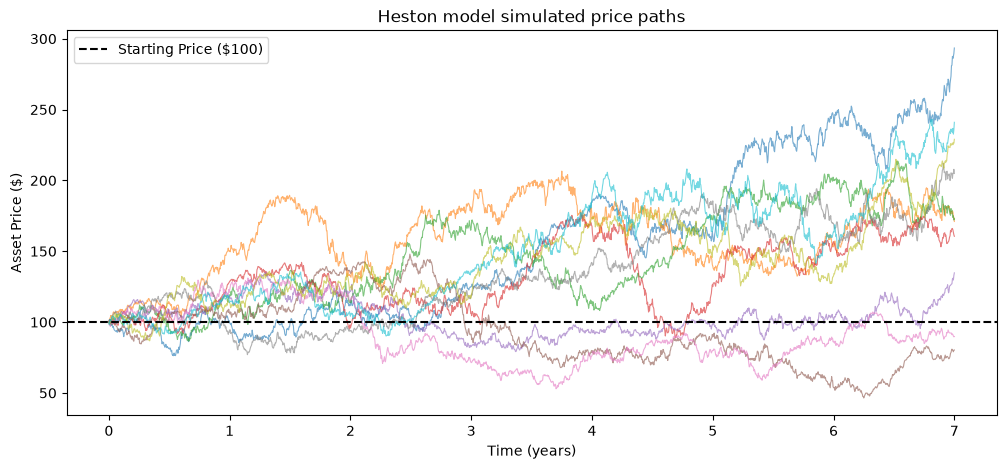

In [84]:
plt.figure(figsize=(12, 5))
plt.plot(times, S_hest, lw=0.8, alpha=0.6)
plt.axhline(S0, color='k', linestyle='--', label=f'Starting Price (${S0})')
plt.title("Heston model simulated price paths")
plt.xlabel("Time (years)")
plt.ylabel("Asset Price ($)")
plt.legend()
plt.show()


Plot volitility

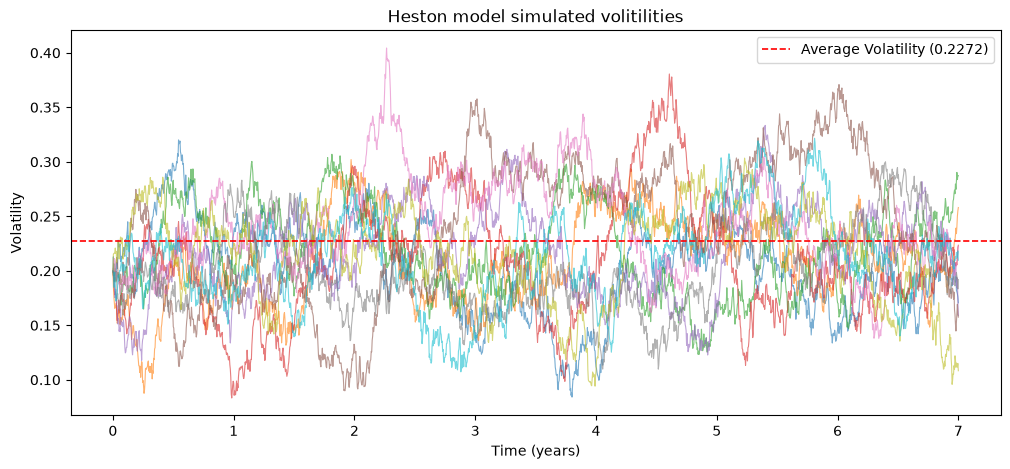

In [85]:
plt.figure(figsize=(12, 5))
plt.plot(times, np.sqrt(v_hest), lw=0.8, alpha=0.6)
plt.axhline(np.sqrt(theta), color='r', linestyle='--', lw=1.2,
            label=f'Average Volatility ({np.sqrt(theta):.4f})')
plt.title("Heston model simulated volitilities")
plt.xlabel("Time (years)")
plt.ylabel("Volatility")
plt.legend()
plt.show()

## Evaluation

Price follows similar paths to GBM model but with less extreme outliers that reach unrealistic prices. Correlation of $\rho$ = -0.7 allows us to model the presence of crashes more accurately.  
Volitility plot now matches real data more accurately than previous model.


